# Vergleich: Greedy vs. Positionales Mapping

Welche HD→IPA-Paare wurden von beiden Methoden gefunden, welche nur von einer, welche von keiner?

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from matplotlib_venn import venn2

plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

df_greedy = pd.read_csv("Data/ostschweiz_mapping_results.csv")
df_pos    = pd.read_csv("Data/ostschweiz_mapping_positional.csv")

# Paare als Tupel-Sets
greedy_pairs = set(zip(df_greedy["Hochdeutsch"], df_greedy["IPA_Dialekt"]))
pos_pairs    = set(zip(df_pos["Hochdeutsch"],    df_pos["IPA_Dialekt"]))

both       = greedy_pairs & pos_pairs
only_greedy = greedy_pairs - pos_pairs
only_pos    = pos_pairs - greedy_pairs

print(f"Greedy-Paare total:      {len(greedy_pairs):>4}")
print(f"Positionale Paare total: {len(pos_pairs):>4}")
print(f"In beiden:               {len(both):>4}")
print(f"Nur Greedy:              {len(only_greedy):>4}")
print(f"Nur Positional:          {len(only_pos):>4}")

Greedy-Paare total:       115
Positionale Paare total:  594
In beiden:                 81
Nur Greedy:                34
Nur Positional:           513


## 1. Übersicht – Venn-Diagramm & Balken

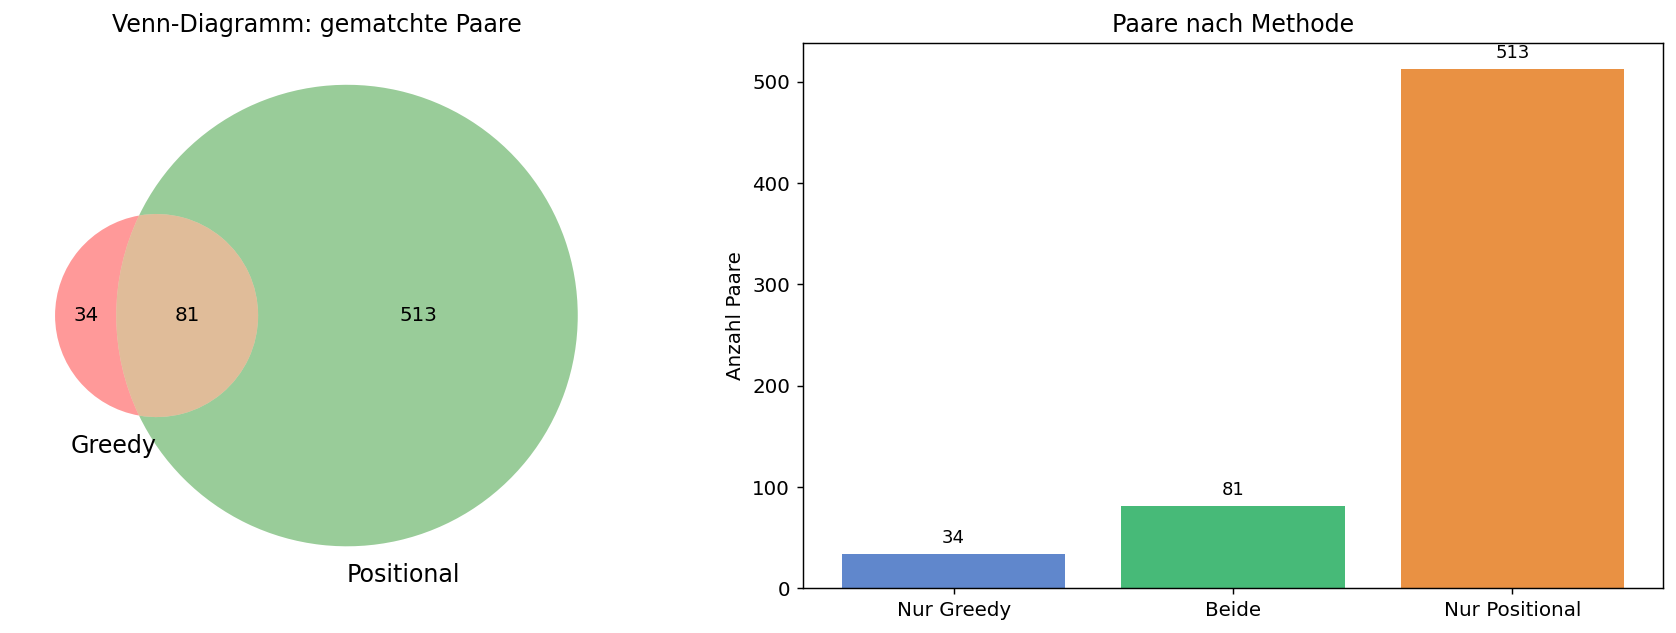

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Venn
try:
    venn2([greedy_pairs, pos_pairs], set_labels=("Greedy", "Positional"), ax=axes[0])
    axes[0].set_title("Venn-Diagramm: gematchte Paare")
except Exception:
    axes[0].text(0.5, 0.5, "matplotlib-venn nicht installiert\npip install matplotlib-venn",
                 ha="center", va="center", transform=axes[0].transAxes, fontsize=10)
    axes[0].set_title("Venn-Diagramm (nicht verfügbar)")

# Balken
labels = ["Nur Greedy", "Beide", "Nur Positional"]
values = [len(only_greedy), len(both), len(only_pos)]
colors = ["#4472C4", "#27AE60", "#E67E22"]
bars = axes[1].bar(labels, values, color=colors, alpha=0.85)
axes[1].bar_label(bars, padding=4, fontsize=10)
axes[1].set_ylabel("Anzahl Paare")
axes[1].set_title("Paare nach Methode")

plt.tight_layout()
plt.show()

## 2. HD-Wörter: Übereinstimmung des IPA-Partners

Für HD-Wörter die **beide** Methoden gefunden haben: Stimmt der zugewiesene IPA-Token überein?

HD-Wörter in beiden Methoden: 86
  Gleicher IPA-Token:         35  (40.7%)
  Unterschiedlicher IPA-Token: 51  (59.3%)


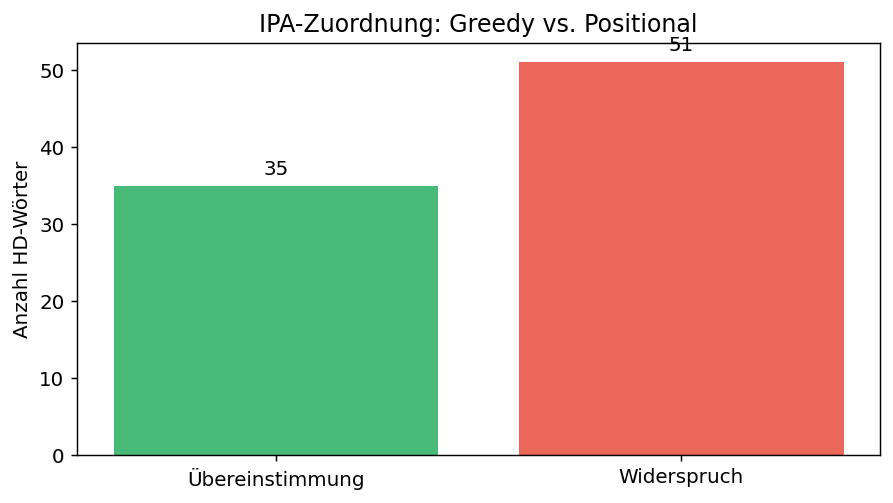

In [3]:
greedy_dict = dict(zip(df_greedy["Hochdeutsch"], df_greedy["IPA_Dialekt"]))
pos_dict    = dict(zip(df_pos["Hochdeutsch"],    df_pos["IPA_Dialekt"]))

common_hd = set(greedy_dict) & set(pos_dict)

agree    = [(w, greedy_dict[w]) for w in common_hd if greedy_dict[w] == pos_dict[w]]
disagree = [(w, greedy_dict[w], pos_dict[w]) for w in common_hd if greedy_dict[w] != pos_dict[w]]

print(f"HD-Wörter in beiden Methoden: {len(common_hd)}")
print(f"  Gleicher IPA-Token:         {len(agree)}  ({len(agree)/len(common_hd)*100:.1f}%)")
print(f"  Unterschiedlicher IPA-Token: {len(disagree)}  ({len(disagree)/len(common_hd)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(["Übereinstimmung", "Widerspruch"], [len(agree), len(disagree)],
              color=["#27AE60", "#E74C3C"], alpha=0.85)
ax.bar_label(bars, padding=4, fontsize=11)
ax.set_ylabel("Anzahl HD-Wörter")
ax.set_title("IPA-Zuordnung: Greedy vs. Positional")
plt.tight_layout()
plt.show()

## 3. Widersprüche – wo weichen die Methoden ab?

In [4]:
if disagree:
    df_dis = pd.DataFrame(disagree, columns=["Hochdeutsch", "Greedy_IPA", "Positional_IPA"])
    # Greedy-Hits zur Einschätzung hinzufügen
    df_dis = df_dis.merge(
        df_greedy[["Hochdeutsch", "Gemeinsame_Treffer", "Kokkurrenz_Rate", "PMI"]],
        on="Hochdeutsch", how="left"
    )
    df_dis = df_dis.sort_values("Gemeinsame_Treffer", ascending=False).reset_index(drop=True)
    print(f"Widersprüche ({len(df_dis)}):")
    print(df_dis.to_string(index=False))
else:
    print("Keine Widersprüche – beide Methoden stimmen bei allen gemeinsamen HD-Wörtern überein.")

Widersprüche (51):
Hochdeutsch Greedy_IPA Positional_IPA  Gemeinsame_Treffer  Kokkurrenz_Rate    PMI
        und        ʊnt            ʊnd                 143           0.4347 3.0135
         es         ɛs            aʊs                 107           0.3702 2.4776
        für       fyːɾ            fɪr                  84           0.3590 3.3846
         im         ɪm             ɛm                  80           0.4061 3.3836
       sich        zɪç          zɪçtə                  72           0.3547 3.7201
        ich         ɪç             ɪs                  68           0.3285 2.8047
        mit        mɪt         miːtən                  45           0.2830 3.9367
     werden      vɛɾdə            vɛɾ                  45           0.2866 4.2332
        hat        hɛt             ɛt                  45           0.3409 3.1926
        als        als             ɛs                  43           0.5000 4.8901
       auch         aʊ            ɑːl                  35           0.1570 3.74

## 4. Nur-Greedy-Paare – Top 30

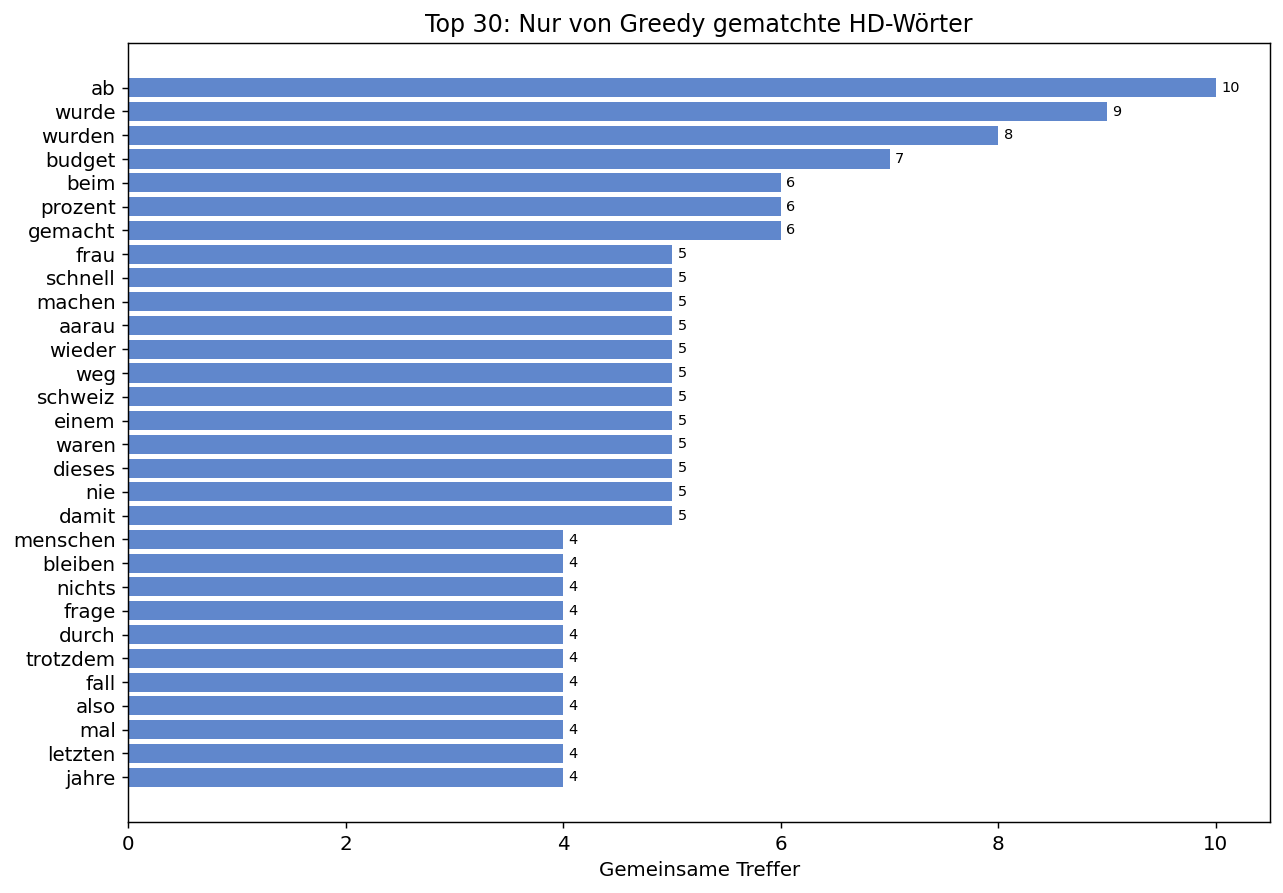

In [5]:
df_only_greedy = (
    df_greedy[df_greedy["Hochdeutsch"].isin({p[0] for p in only_greedy})]
    .sort_values("Gemeinsame_Treffer", ascending=False)
    .head(30)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    df_only_greedy["Hochdeutsch"][::-1],
    df_only_greedy["Gemeinsame_Treffer"][::-1],
    color="#4472C4", alpha=0.85
)
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_xlabel("Gemeinsame Treffer")
ax.set_title("Top 30: Nur von Greedy gematchte HD-Wörter")
plt.tight_layout()
plt.show()

## 5. Nur-Positional-Paare – Top 30

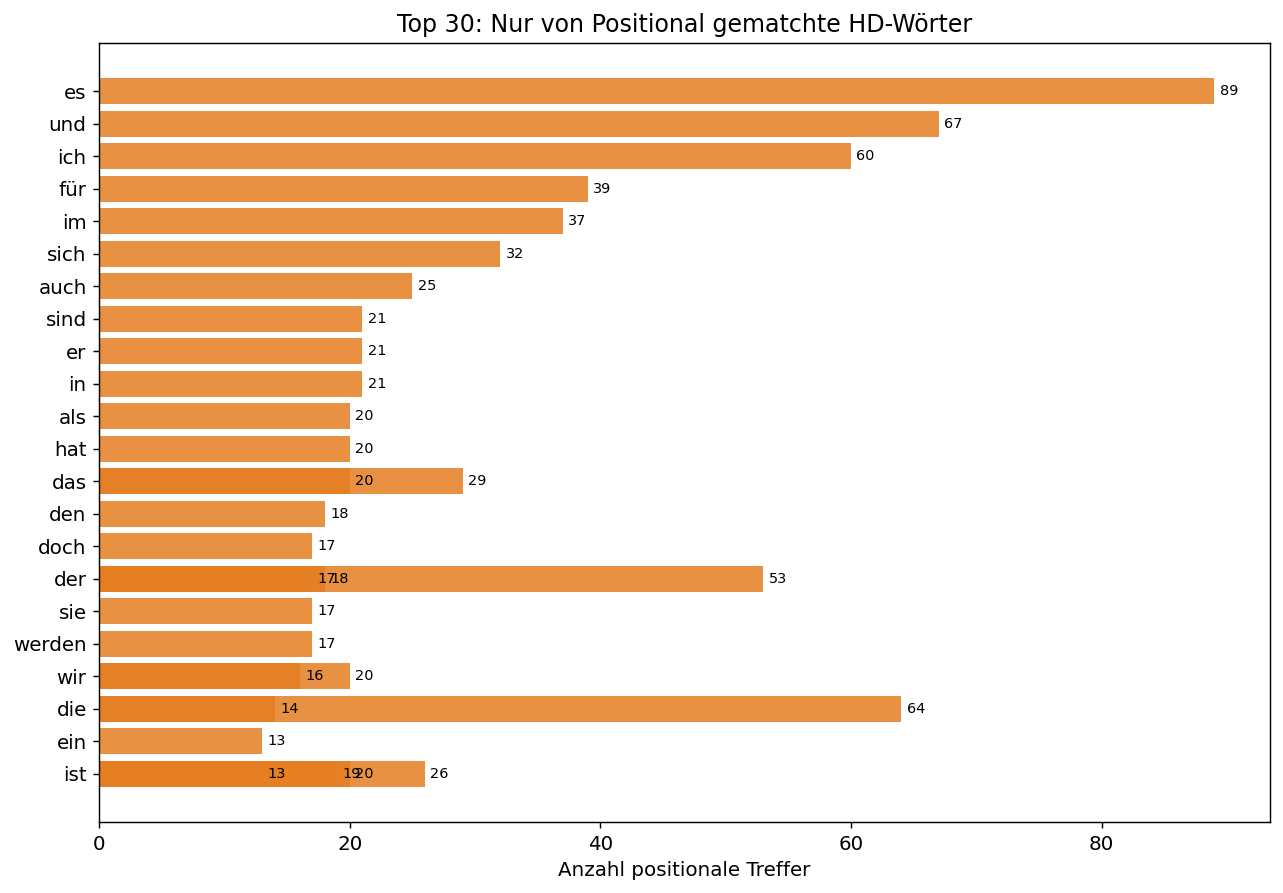

In [6]:
df_only_pos = (
    df_pos[df_pos["Hochdeutsch"].isin({p[0] for p in only_pos})]
    .sort_values("Anzahl", ascending=False)
    .head(30)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    df_only_pos["Hochdeutsch"][::-1],
    df_only_pos["Anzahl"][::-1],
    color="#E67E22", alpha=0.85
)
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_xlabel("Anzahl positionale Treffer")
ax.set_title("Top 30: Nur von Positional gematchte HD-Wörter")
plt.tight_layout()
plt.show()

## 6. Gemeinsame Paare – Qualitätscheck

Für die von beiden Methoden übereinstimmend gefundenen Paare: Greedy-Scores anzeigen.

In [7]:
agree_hd = {w for w, _ in agree}
df_agree = (
    df_greedy[df_greedy["Hochdeutsch"].isin(agree_hd)]
    .sort_values("Gemeinsame_Treffer", ascending=False)
    .reset_index(drop=True)
)
print(f"Übereinstimmende Paare ({len(df_agree)}):")
print(df_agree[["Hochdeutsch", "IPA_Dialekt", "Gemeinsame_Treffer",
                "Kokkurrenz_Rate", "IPA_Kokkurrenz_Rate", "PMI"]].to_string(index=False))

Übereinstimmende Paare (35):
Hochdeutsch IPA_Dialekt  Gemeinsame_Treffer  Kokkurrenz_Rate  IPA_Kokkurrenz_Rate    PMI
       nach         nɔx                  32           0.5246               0.6809 5.1053
        vom         fɔm                  13           0.6500               0.4643 6.1617
        aus          ʊs                  13           0.1548               0.7647 4.8112
      dafür        fyːɾ                  12           0.3750               0.5455 5.7161
    bereits     bəraɪts                  12           0.3243               1.0000 6.3811
      hatte         hɛt                  12           0.3871               0.1714 4.0921
       ganz       gants                  11           0.4583               0.9167 6.8801
         um          ʊm                  11           0.2000               0.4074 4.5138
      dabei         biː                  11           0.3143               0.5000 5.4613
       viel        fiːl                   9           0.3000               0.5000